# **Probability and Rules of Probability**
___

### Understanding Fundamental Concepts in Probability

Before delving into the intricacies of probability, it's essential to grasp some fundamental terms and definitions associated with it.

#### Random Experiment:
A random experiment is characterized by its unpredictable outcomes when repeated under identical conditions. Examples include rolling a die or tossing an unbiased coin.

#### Outcome:
An outcome refers to the result obtained from a single trial of an experiment.

#### Sample Space:
The sample space represents a comprehensive list encompassing all potential outcomes of an experiment. For instance, in the case of tossing a coin, the sample space would be $\{Heads, Tails\}$, while for rolling a die, it would consist of $\{1, 2, 3, 4, 5, 6\}$.

#### Event:
An event denotes a subset of the sample space and can comprise either a single outcome or a combination of outcomes. For instance, obtaining at least two heads in a row when a coin is tossed four times constitutes an event. Another example could involve getting heads on a coin and rolling a six on a die simultaneously.

### Probability:

Probability serves as a quantifiable measure of the likelihood of an event occurring.

**Note:** Events cannot be predicted with absolute certainty. Probability allows us to assess the likelihood of an event happening, ranging between 0 and 1. A probability of "Zero" signifies that the event is impossible, while a value of "One" indicates certainty.

The probability of an event $A$, denoted as $P(A)$, is calculated using the formula:

$$ P(A) = \frac {n(A)}{n(S)} $$

where:  
- $P(A)$ represents the probability of event $A$ occurring.  
- $n(A)$ denotes the number of favorable outcomes for event $A$.  
- $n(S)$ signifies the total number of possible outcomes.

**Example:**  
The probability of rolling a number less than or equal to 2 when tossing a dieis $\frac{2}{6} = \frac{1}{3}$.


### **Rules of Probability**

Understanding the rules governing probability is crucial for accurate analysis and interpretation.

+ The probability of an event can range anywhere from 0 to 1:  
  $0 \leq P(A) \leq 1.$  
  This signifies that probabilities lie within the range of certainty from impossible (0) to certain (1).

+ Sum of all probabilities should add up to 1  
  $P(A) + P(\overline{A}) = 1.$  
  This rule highlights that the combined probability of an event occurring and not occurring is always equal to 1.

+ Complementary Rule - Probability of event A not happening:  
  $P(\overline{A})=1-P(A).$  
  It indicates that the probability of an event not occurring is equal to 1 minus the probability of the event occurring.  

+ Addition Rule (A and B are not necessarily disjoint) - Probability of A happening or B happening:  
  $P(A\cup B)=P(A)+P(B)-P(A\cap B).$  
  This rule calculates the probability of either event A or event B happening, accounting for the overlap if they are not mutually exclusive  

+ Addition Rule (A and B are disjoint) - Probability of A happening or B happening:  
  $P(A\cup B)=P(A)+P(B).$  
  This rule simplifies the addition of probabilities when events A and B are mutually exclusive.  
 
+ Multiplication Rule - Chain Rule:  
  $P(A\cap B)=P(A)*P(B|A)=P(B)*P(A|B).$  
  This rule computes the joint probability of events A and B occurring, taking into account the conditional probabilities.  

+ If A and B are independent events, then:  
  $P(A\cap B)=P(A)*P(B).$  
  This implies that the occurrence of one event does not affect the probability of the other event.  

+ $P(A\setminus B)=P(A)-P(A\cap B).$  
  This rule calculates the probability of event A happening excluding the outcomes also included in event B.  

+ $If A\subset B, \text{then}\ P(A)\leq P(B).$  
  This indicates that the probability of a subset event A is always less than or equal to the probability of the superset event B.  

+ $P(\emptyset)=0. $  
  The probability of the empty set is always zero.  

## **Conditional Probability**

Conditional probability of event **A** given event **B** is the probability that **A** occurs given that **B** has occurred.

$$P(A|B)=\frac{P(A\cap B)}{P(B)}\,.$$

Let's illustrate this with an example:

Suppose we roll a fair die, and let event A be the outcome being an odd number (i.e., A={1,3,5}), and event B be the outcome being less than or equal to 3 (i.e., B={1,2,3}). What is the probability of A given B, $P(A|B)$?

$$P(B) = \frac{3}{6} \quad , \quad P(A \cap B) = \frac{2}{6}$$ 

$$P(A|B) = \frac{2}{3}$$


## **Law of Large Numbers**

The law of large numbers asserts that as the sample size increases, the average or mean of the sample values will converge towards the expected value.

This principle can be exemplified through a basic scenario of flipping a coin. With a coin having equal chances of landing heads or tails, the expected probability of it landing heads is 1/2 or 0.5 over an infinite number of flips.

However, if we only flip the coin 10 times, we may observe a deviation from the expected value. For instance, the coin might land heads only 3 times out of the 10 flips, which doesn't align closely with the expected probability of 0.5. This discrepancy is due to the relatively small sample size.

As the number of flips increases, say to 20 or 30 times, we would expect the proportion of heads to gradually approach 0.5. For instance, after 20 flips, we might see 9 heads, and after 30 flips, we might observe 22 heads. With a larger sample size, the observed proportion of heads tends to converge towards the expected value of 0.5.


<center><img src="./data/lln.png"/></center>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(seed=42)


---
## Law of Large Numbers — Simulation

As the number of coin flips grows, the observed proportion of heads converges to
the true probability **P(Heads) = 0.5**. Convergence is guaranteed only for
distributions with **finite mean** (the Cauchy distribution is a famous exception).

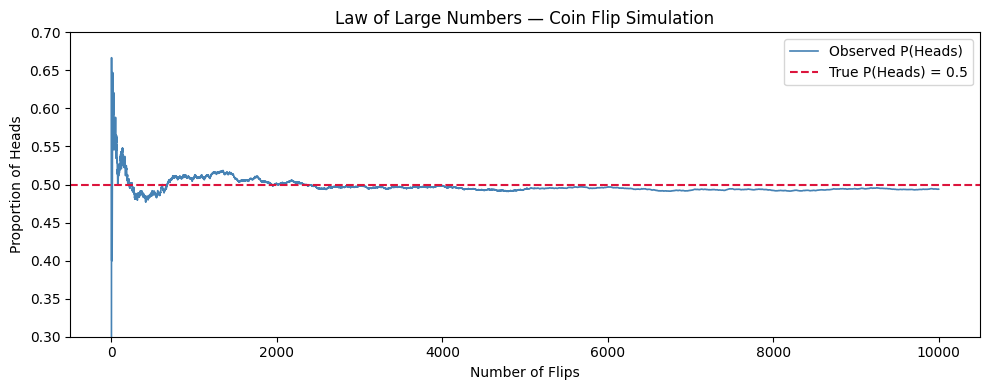

Final proportion after 10,000 flips: 0.4939


In [2]:
n_flips = 10_000
flips = rng.choice([0, 1], size=n_flips)   # 0=Tails, 1=Heads
running_prop = np.cumsum(flips) / np.arange(1, n_flips + 1)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(running_prop, color='steelblue', lw=1.2, label='Observed P(Heads)')
ax.axhline(0.5, color='crimson', lw=1.5, ls='--', label='True P(Heads) = 0.5')
ax.set_xlabel('Number of Flips')
ax.set_ylabel('Proportion of Heads')
ax.set_title('Law of Large Numbers — Coin Flip Simulation')
ax.legend()
ax.set_ylim(0.3, 0.7)
plt.tight_layout()
plt.show()
print(f'Final proportion after {n_flips:,} flips: {running_prop[-1]:.4f}')


---
## Conditional Probability — Worked Example in Code

Fair die: **A** = odd {1,3,5}, **B** = ≤3 {1,2,3}.  
We want **P(A|B)** — probability of rolling odd, *given* it's ≤ 3.

In [3]:
sample_space = list(range(1, 7))
A = {x for x in sample_space if x % 2 != 0}   # odd
B = {x for x in sample_space if x <= 3}        # <= 3
A_and_B = A & B

P_B       = len(B)       / len(sample_space)
P_AandB   = len(A_and_B) / len(sample_space)
P_A_gvn_B = P_AandB / P_B

print(f'A (odd):         {sorted(A)}')
print(f'B (<=3):         {sorted(B)}')
print(f'A intersect B:   {sorted(A_and_B)}')
print()
print(f'P(B)     = {len(B)}/{len(sample_space)} = {P_B:.4f}')
print(f'P(A^B)   = {len(A_and_B)}/{len(sample_space)} = {P_AandB:.4f}')
print(f'P(A|B)   = P(A^B)/P(B) = {P_AandB:.4f}/{P_B:.4f} = {P_A_gvn_B:.4f}')
print(f'\nGiven the die is <=3, there is a {P_A_gvn_B:.1%} chance it is odd.')


A (odd):         [1, 3, 5]
B (<=3):         [1, 2, 3]
A intersect B:   [1, 3]

P(B)     = 3/6 = 0.5000
P(A^B)   = 2/6 = 0.3333
P(A|B)   = P(A^B)/P(B) = 0.3333/0.5000 = 0.6667

Given the die is <=3, there is a 66.7% chance it is odd.
